In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


## Khảo sát số cụm K

Đang thử K = 2
Đang thử K = 3
Đang thử K = 4
Đang thử K = 5
Đang thử K = 6

===== BẢNG SO SÁNH K =====


,K,Inertia,Silhouette Score
0,2,29917.96,0.4701
1,3,18432.55,0.4877
2,4,13832.24,0.4525
3,5,10194.79,0.4690
4,6,8710.62,0.4336


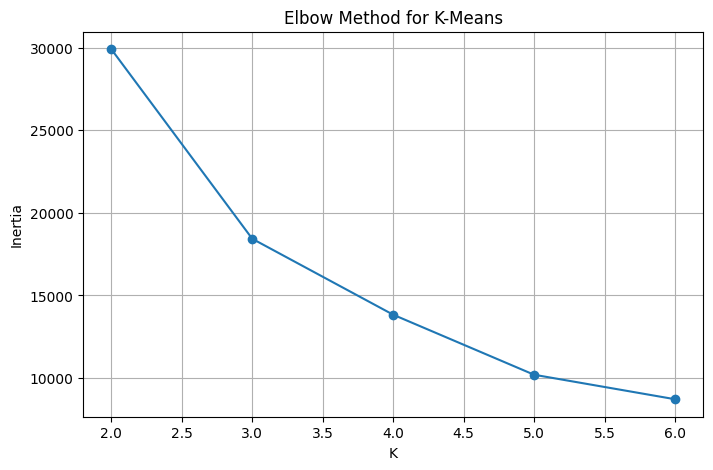

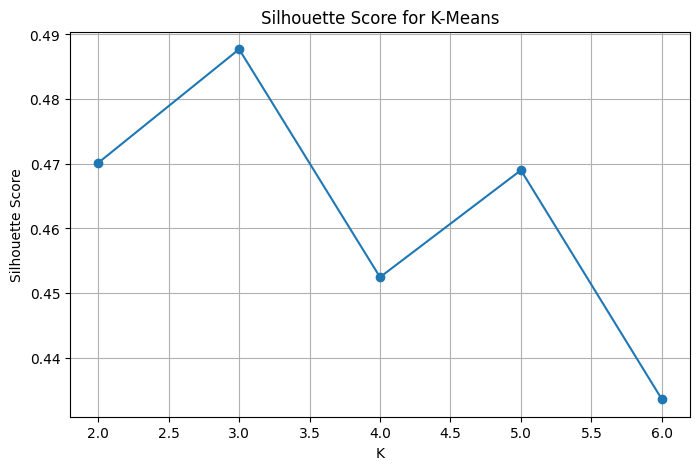


K tốt nhất theo Silhouette Score là: 3


In [2]:
# --- KHẢO SÁT SỐ CỤM K CHO K-MEANS ---


# 1. Đọc dữ liệu train
df_train = pd.read_csv("traffic_train_with_features.csv")

# 2. Bộ feature đã chọn
best_features = [
    'traffic_volume', 
    'avg_24h', 
    'volume_deviation'
]

# 3. Lấy dữ liệu đầu vào
X_raw = df_train[best_features].values

# 4. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ==========================================
# KHẢO SÁT K = 2 -> 6
# ==========================================

results = []

inertias = []
silhouette_scores = []

for k in range(2, 7):

    print(f"Đang thử K = {k}")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    labels = kmeans.labels_

    inertia = kmeans.inertia_

    silhouette = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)

    results.append({
        "K": k,
        "Inertia": round(inertia, 2),
        "Silhouette Score": round(silhouette, 4)
    })

# ==========================================
# HIỂN THỊ BẢNG KẾT QUẢ
# ==========================================

results_df = pd.DataFrame(results)

print("\n===== BẢNG SO SÁNH K =====")
display(results_df)

# ==========================================
# ELBOW METHOD PLOT
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 7),
    inertias,
    marker='o'
)

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.grid(True)

plt.show()

# ==========================================
# SILHOUETTE SCORE PLOT
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 7),
    silhouette_scores,
    marker='o'
)

plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")

plt.grid(True)

plt.show()

# ==========================================
# CHỌN K TỐT NHẤT
# ==========================================

best_k = results_df.loc[
    results_df['Silhouette Score'].idxmax(),
    'K'
]

print(f"\nK tốt nhất theo Silhouette Score là: {best_k}")

## Chạy Training K_Means

In [ ]:
# --- TRAINING VỚI K=3

# 1. Đọc dữ liệu train đã có feature
train_features = pd.read_csv("traffic_train_hmm_output.csv")

# 2. Bộ feature đã chọn
best_features = [
    'traffic_volume', 
    'avg_24h', 
    'volume_deviation'
]

# 3. Lấy dữ liệu
X_raw = train_features[best_features].values

# 4. Chuẩn hóa dữ liệu
kmeans_scaler = StandardScaler()
X_scaled = kmeans_scaler.fit_transform(X_raw)

# 5. Train K-Means
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_scaled)

# 6. Gán cụm K-Means cho train
train_features['kmeans_state'] = kmeans_model.labels_

# 7. Hiển thị tâm cụm sau khi inverse scale về giá trị gốc
centers_original = kmeans_scaler.inverse_transform(kmeans_model.cluster_centers_)

centers_df = pd.DataFrame(
    centers_original,
    columns=best_features
)

centers_df.index = [f"Cluster_{i}" for i in range(3)]

print("KMEANS CLUSTER CENTERS")
display(centers_df.round(2))

# 8. Phân bố cụm
cluster_dist_df = (
    train_features['kmeans_state']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

cluster_dist_df.columns = ["KMeans State", "Percentage (%)"]

print("KMEANS STATE DISTRIBUTION")
display(cluster_dist_df)

# 9. Trung bình feature theo cụm
cluster_summary = (
    train_features
    .groupby('kmeans_state')[best_features]
    .mean()
    .round(2)
)

print("FEATURE MEAN BY KMEANS STATE")
display(cluster_summary)

# 10. Lưu model và scaler
joblib.dump(kmeans_model, "kmeans_model.pkl")
joblib.dump(kmeans_scaler, "kmeans_scaler.pkl")

# 11. Lưu file train có cả state K-Means
train_features.to_csv("traffic_train_model_output.csv", index=False)

print("\nĐã lưu:")
print("- kmeans_model.pkl")
print("- kmeans_scaler.pkl")
print("- traffic_train_with_kmeans_states.csv")

KMEANS CLUSTER CENTERS


,traffic_volume,avg_24h,volume_deviation
Cluster_0,5081.22,3450.58,1630.64
Cluster_1,2289.57,2549.34,-259.78
Cluster_2,1425.57,3559.83,-2134.25


KMEANS STATE DISTRIBUTION


,KMeans State,Percentage (%)
0,0,46.19
1,1,21.19
2,2,32.63


FEATURE MEAN BY KMEANS STATE


,traffic_volume,avg_24h,volume_deviation
kmeans_state,,,
0,5079.62,3450.00,1629.61
1,2285.23,2548.44,-263.21
2,1425.40,3559.92,-2134.52



Đã lưu:
- kmeans_model.pkl
- kmeans_scaler.pkl
- traffic_train_with_kmeans_states.csv
